# Computer Exercise 15.31 — Problem 2
## $T^\star$ 에서의 재판정 — 분해능은 예산에 단조가 아니다

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.31
> **단원**: Ch 15 Sequential Decision Making — §15.31 Measurement Instrument Repair
> **풀이 일자**: 2026-08-16 (Day 98)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Problem 1 이 찾은 예산 범위에서 baseline 과 +CNRT 를 **동일 시드로 짝지어** 다시 비교한다. 관심은 승패가 아니라 **필요 시드 수 $n^\star$ 가 예산에 따라 어떻게 움직이는가** 이다.

## 1. 문제 (원문)

> **Computer Exercise 15.31.2.** Using the budget range established in Exercise 15.31.1, re-adjudicate
> the baseline $Q$-learner against the $+$CNRT variant (Factorized Noisy Linear head) at
> $T \in \{400,\ 10\,000,\ 50\,000\}$ with $30$ common seeds and common random numbers at deployment.
> Report the paired difference $\bar d$, a bootstrap $95\%$ confidence interval, the sign pattern
> across seeds, and the sample size $n^\star$ required for $80\%$ power. State whether increasing the
> budget *restores* the resolving power of the benchmark. Additionally, track the mean noise scale
> $\bar\sigma(T)$ of the Noisy head at the end of training and explain any non-monotonicity in
> $n^\star$ in terms of it.

### 한국어 풀이용 정리

- **비교 대상**: `baseline` ($\varepsilon$-greedy 탐색) 대 `+CNRT` (Factorized Noisy Linear 헤드 탐색).
- **설계**: 30 시드 공통, 배포 난수도 시드 인덱스에만 의존 → **완전 짝지은(paired) 비교**.
- **1차 지표**: 짝지은 차 $d_i = R_i^{+\text{CNRT}} - R_i^{\text{base}}$, 평균 $\bar d$,
  bootstrap 95% CI, 부호 패턴(승/무/패), 필요 시드 수 $n^\star$.
- **부수 진단**: 학습 종료 시점의 Noisy 헤드 평균 잡음 스케일 $\bar\sigma$.
  이것이 $n^\star$ 의 비단조성을 설명하는 열쇠다.
- **주의**: 이 노트북의 목적은 "+CNRT 가 좋다/나쁘다" 를 선언하는 것이 **아니다**.
  같은 질문을 세 예산에서 물었을 때 **답의 확신도가 어떻게 변하는지**를 재는 것이다.

## 2. 수학적 배경

### 2.1 두 arm

**baseline** — 결정적 선형 헤드 + $\varepsilon$-greedy:

$$a_t = \begin{cases}\text{Unif}(\mathcal A) & \text{prob. } \varepsilon = 0.1\\
\arg\max_a Q_\theta(s_t,a) & \text{otherwise}\end{cases}$$

**+CNRT** — Factorized Noisy Linear 헤드 (Fortunato et al., 2018). 헤드 가중치가
평균 $\mu$ 와 스케일 $\sigma$ 의 쌍으로 분해되고, 에피소드마다 잡음이 재표집된다:

$$W_2^{\text{eff}} = \mu_W + \sigma_W \odot \varepsilon_W,\qquad
\varepsilon_W = f(\varepsilon^{\text{out}})\,f(\varepsilon^{\text{in}})^{\!\top},\quad
f(z) = \mathrm{sgn}(z)\sqrt{|z|}$$

초기값은 $\sigma_{ij} = \sigma_0/\sqrt H$ ($\sigma_0 = 0.5$, $H = 16$). 행동 선택은 잡음이 실린
$Q$ 에 대해 **탐욕적**이며 $\varepsilon$-greedy 를 쓰지 않는다. $\sigma$ 는 학습 가능한 파라미터로,
$\mu$ 와 **동일한 TD 손실**의 기울기를 받는다:

$$\frac{\partial \mathcal L}{\partial \sigma_W} = \frac{\partial \mathcal L}{\partial W_2^{\text{eff}}}\odot \varepsilon_W$$

### 2.2 짝지은 추정과 검정력

시드 $i$ 에 대해 $d_i = R_i^{+\text{CNRT}} - R_i^{\text{base}}$. 두 arm 이 **같은 시드**로 초기화되고
**같은 배포 난수**로 평가되므로, Problem 1 에서 확인한 거대한 초기화 분산이 차분에서 상쇄된다.

$$\bar d = \frac1n\sum_i d_i,\qquad
\widehat{\mathrm{CI}}_{95} = \bigl[\,q_{2.5}(\bar d^{*(b)}),\ q_{97.5}(\bar d^{*(b)})\,\bigr]$$

($B = 20\,000$ 회 비모수 bootstrap 재표집). 80% 검정력에 필요한 시드 수:

$$\boxed{\ n^\star(T) = \Bigl\lceil \bigl(2.8\,\mathrm{sd}(d)/|\bar d|\bigr)^2\Bigr\rceil\ }$$

$n^\star$ 는 **효과 크기 대비 잡음의 비율**이다. 따라서

$$n^\star \ \text{가 작다} \iff \text{예산 } T \text{ 에서 이 벤치마크는 두 arm 을 잘 분리한다}$$

### 2.3 비단조성의 예고

$n^\star(T)$ 가 $T$ 에 대해 단조 감소하리라는 보장은 없다. 분모의 $|\bar d|$ 도 $T$ 의 함수이기 때문이다.
두 arm 이 **모두** 최적 정책으로 수렴하면 $\bar d \to 0$ 이고 $n^\star \to \infty$ 가 된다.
즉 벤치마크의 분해능은

$$T \text{ 작음: } \mathrm{sd}(d) \text{ 큼} \Rightarrow n^\star \text{ 큼}
\qquad\qquad
T \text{ 큼: } |\bar d| \to 0 \Rightarrow n^\star \text{ 큼}$$

의 **양쪽 끝에서 무너지고 중간에서 최대**가 될 수 있다. 이 노트북은 그 곡선을 실제로 그린다.

## 3. 풀이 흐름

1. 30 시드 $\{98201,\dots,98230\}$ 를 세 예산 $\times$ 두 arm 에 **모두 공통**으로 사용.
2. 각 조합에서 학습 → freeze → greedy 정책 추출 → 배포 (slip $0.20$, 40 에피소드).
   배포 난수는 시드 인덱스에만 의존시켜 **공통난수** 를 보장.
3. 시드별 지표를 먼저 계산하고(**seed-first**), 그 다음에 차분 $d_i$ 를 만든다.
   (평균을 먼저 내고 빼는 avg-first 추정량은 짝지음의 이점을 잃는다.)
4. $\bar d$, bootstrap 95% CI ($B=20\,000$), 승/무/패 부호 패턴, $n^\star$ 산출.
5. Noisy 헤드의 종료 시점 평균 $\bar\sigma$ 를 예산별로 기록.
6. 예산 대 $n^\star$ 곡선과 $\bar\sigma$ 곡선을 나란히 그려 비단조성의 원인을 지목.
7. 결론은 **CI 가 0 을 포함하면 "차이를 확인하지 못했다"** 로 쓴다.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–97 과 동일 계열의 5-상태 chain MDP 재구성) ──────
import numpy as np

NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL = 0.95, 0.05, 16, 0.25

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

class Learner:
    """Trunk MLP (tanh) + linear head. noisy=True -> Factorized Noisy Linear head."""
    def __init__(self, rng, noisy=False, sigma0=0.5, h=H):
        self.h, self.noisy = h, noisy
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        if noisy:
            self.Ws = np.full((NA, h), sigma0 / np.sqrt(h))
            self.bs = np.full(NA, sigma0 / np.sqrt(h))
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.noisy: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        W = self.W2 + (self.Ws * self.eps_W if (noise and self.noisy) else 0.0)
        b = self.b2 + (self.bs * self.eps_b if (noise and self.noisy) else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.noisy:
            self.Ws -= ETA * (gW2 * self.eps_W)
            self.bs -= ETA * (gb2 * self.eps_b)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, p_train=0.20, noisy=False, eps_greedy=0.10):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, noisy=noisy)
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if noisy:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """Frozen greedy evaluation; mean reward per step."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

print("chain MDP:  states =", NS, " actions =", NA, " episode len =", L)
print("gamma =", GAMMA, " lr =", ETA, " trunk H =", H, " local reward =", R_LOCAL)

chain MDP:  states = 5  actions = 2  episode len = 20
gamma = 0.95  lr = 0.05  trunk H = 16  local reward = 0.25


In [2]:
# ── P2: 세 예산 x 두 arm, 30 시드 짝지음 ─────────────────────────────────
BUDGETS = [400, 10000, 50000]
SEEDS   = list(range(98201, 98231))          # 30 시드
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
B_BOOT  = 20000

def run_arm(T, noisy):
    ls = [train(s, T, noisy=noisy) for s in SEEDS]
    R  = np.array([deploy(l, P_DEPLOY, N_EP, 7000 + i) for i, l in enumerate(ls)])  # 공통난수
    rec = np.array([greedy_policy(l) == PI_STAR for l in ls])
    sig = np.mean([l.Ws.mean() for l in ls]) if noisy else np.nan
    return R, rec, sig

raw = {}
for T in BUDGETS:
    for noisy in (False, True):
        raw[(T, noisy)] = run_arm(T, noisy)
        arm = "+CNRT " if noisy else "base  "
        print(f"T={T:>6d} {arm} R={raw[(T,noisy)][0].mean():.4f}  rec={raw[(T,noisy)][1].mean():.2f}")

T=   400 base   R=0.3789  rec=0.47


T=   400 +CNRT  R=0.2927  rec=0.27


T= 10000 base   R=0.5507  rec=0.87


T= 10000 +CNRT  R=0.3635  rec=0.43


T= 50000 base   R=0.5356  rec=0.83


T= 50000 +CNRT  R=0.5288  rec=0.70


In [3]:
# ── 짝지은 차, bootstrap CI, 검정력 ──────────────────────────────────────
def boot_ci(d, B=B_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return np.percentile(d[idx].mean(axis=1), [2.5, 97.5])

def n_star(d):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((2.8 * s / m) ** 2)) if m > 1e-12 else np.inf

rows = []
diffs = {}
for T in BUDGETS:
    Rb, recb, _   = raw[(T, False)]
    Rc, recc, sig = raw[(T, True)]
    d = Rc - Rb
    diffs[T] = d
    lo, hi = boot_ci(d)
    rows.append(dict(T=T, R_base=Rb.mean(), R_cnrt=Rc.mean(),
                     rec_base=recb.mean(), rec_cnrt=recc.mean(),
                     d_bar=d.mean(), ci_lo=lo, ci_hi=hi, sd_d=d.std(ddof=1),
                     n_star=n_star(d), sigma_end=sig,
                     win=int((d > 1e-9).sum()), tie=int((np.abs(d) <= 1e-9).sum()),
                     loss=int((d < -1e-9).sum())))
res = pd.DataFrame(rows)

print("표 1 — baseline vs +CNRT, 30 시드 짝지은 비교")
print(res[["T", "R_base", "R_cnrt", "d_bar", "ci_lo", "ci_hi", "sd_d", "n_star"]].to_string(index=False))
print("\n표 2 — 부호 패턴 · 회복률 · Noisy head 잡음 스케일")
print(res[["T", "win", "tie", "loss", "rec_base", "rec_cnrt", "sigma_end"]].to_string(index=False))

print("\n판정 (CI 가 0 을 포함하면 '차이를 확인하지 못했다'):")
for _, r in res.iterrows():
    excl = (r.ci_lo > 0) or (r.ci_hi < 0)
    verdict = ("+CNRT 우위 확인" if r.d_bar > 0 else "baseline 우위 확인") if excl else "차이 확인 실패 (0 in CI)"
    print(f"  T={int(r['T']):>6d}: d={r.d_bar:+.4f}  CI[{r.ci_lo:+.4f},{r.ci_hi:+.4f}]  "
          f"n*={r.n_star:>6}  ->  {verdict}")

표 1 — baseline vs +CNRT, 30 시드 짝지은 비교
    T  R_base  R_cnrt   d_bar   ci_lo   ci_hi   sd_d  n_star
  400  0.3789  0.2927 -0.0862 -0.1605 -0.0097 0.2160      50
10000  0.5507  0.3635 -0.1872 -0.2581 -0.1129 0.2073      10
50000  0.5356  0.5288 -0.0068 -0.0635  0.0469 0.1563    4101

표 2 — 부호 패턴 · 회복률 · Noisy head 잡음 스케일
    T  win  tie  loss  rec_base  rec_cnrt  sigma_end
  400    2   14    14    0.4667    0.2667     0.1490
10000    1   12    17    0.8667    0.4333     0.3664
50000    5   18     7    0.8333    0.7000     0.8631

판정 (CI 가 0 을 포함하면 '차이를 확인하지 못했다'):
  T=   400: d=-0.0862  CI[-0.1605,-0.0097]  n*=  50.0  ->  baseline 우위 확인
  T= 10000: d=-0.1872  CI[-0.2581,-0.1129]  n*=  10.0  ->  baseline 우위 확인
  T= 50000: d=-0.0068  CI[-0.0635,+0.0469]  n*=4101.0  ->  차이 확인 실패 (0 in CI)


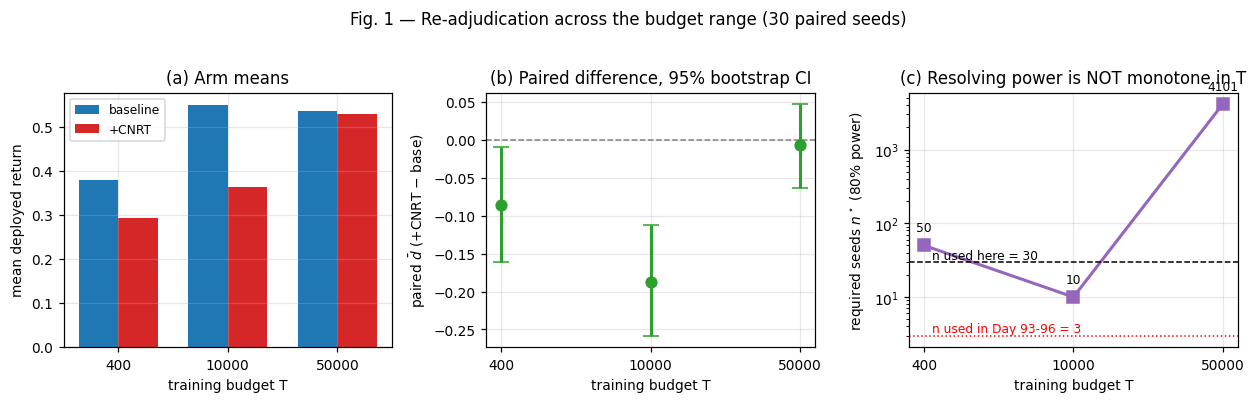

In [4]:
# ── 그림 1: 예산에 따른 arm 분리와 분해능 ────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.5))
x = np.arange(len(BUDGETS)); w = 0.36

ax[0].bar(x - w/2, res["R_base"], w, label="baseline", color="#1f77b4")
ax[0].bar(x + w/2, res["R_cnrt"], w, label="+CNRT", color="#d62728")
ax[0].set_xticks(x); ax[0].set_xticklabels([str(t) for t in BUDGETS])
ax[0].set_xlabel("training budget T"); ax[0].set_ylabel("mean deployed return")
ax[0].set_title("(a) Arm means"); ax[0].legend(fontsize=8)

ax[1].axhline(0, c="gray", lw=1, ls="--")
ax[1].errorbar(x, res["d_bar"],
               yerr=[res["d_bar"] - res["ci_lo"], res["ci_hi"] - res["d_bar"]],
               fmt="o", capsize=5, color="#2ca02c", lw=2, ms=7)
ax[1].set_xticks(x); ax[1].set_xticklabels([str(t) for t in BUDGETS])
ax[1].set_xlabel("training budget T"); ax[1].set_ylabel(r"paired $\bar d$ (+CNRT $-$ base)")
ax[1].set_title("(b) Paired difference, 95% bootstrap CI")

ns = res["n_star"].replace(np.inf, np.nan)
ax[2].semilogy(x, ns, "s-", color="#9467bd", lw=2, ms=8)
ax[2].axhline(30, ls="--", c="k", lw=1)
ax[2].annotate("n used here = 30", (0.05, 32), fontsize=8)
ax[2].axhline(3, ls=":", c="r", lw=1)
ax[2].annotate("n used in Day 93-96 = 3", (0.05, 3.3), fontsize=8, color="r")
ax[2].set_xticks(x); ax[2].set_xticklabels([str(t) for t in BUDGETS])
ax[2].set_xlabel("training budget T"); ax[2].set_ylabel(r"required seeds $n^\star$ (80% power)")
ax[2].set_title("(c) Resolving power is NOT monotone in T")
for i, v in enumerate(ns):
    ax[2].annotate(f"{int(v)}", (i, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)

fig.suptitle("Fig. 1 — Re-adjudication across the budget range (30 paired seeds)", y=1.03)
plt.show()

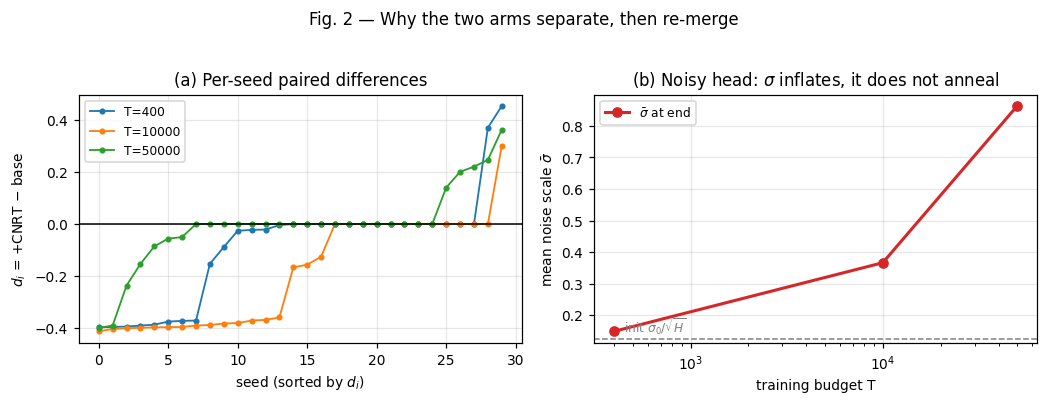

잡음 스케일의 초기값 대비 배율:
  T=   400:  sigma_end=0.1490  (init 0.1250, x1.19)
  T= 10000:  sigma_end=0.3664  (init 0.1250, x2.93)
  T= 50000:  sigma_end=0.8631  (init 0.1250, x6.90)


In [5]:
# ── 그림 2: 시드별 차분과 잡음 스케일 진단 ───────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))

for i, T in enumerate(BUDGETS):
    d = np.sort(diffs[T])
    ax[0].plot(np.arange(len(d)), d, marker="o", ms=3, lw=1.2, label=f"T={T}")
ax[0].axhline(0, c="k", lw=1)
ax[0].set_xlabel("seed (sorted by $d_i$)"); ax[0].set_ylabel(r"$d_i$ = +CNRT $-$ base")
ax[0].set_title("(a) Per-seed paired differences"); ax[0].legend(fontsize=8)

ax2 = ax[1]
ax2.semilogx(res["T"], res["sigma_end"], "o-", color="#d62728", lw=2, label=r"$\bar\sigma$ at end")
ax2.axhline(0.5/np.sqrt(H), ls="--", c="gray", lw=1)
ax2.annotate(r"init $\sigma_0/\sqrt{H}$", (450, 0.5/np.sqrt(H) + .02), fontsize=8, color="gray")
ax2.set_xlabel("training budget T"); ax2.set_ylabel(r"mean noise scale $\bar\sigma$")
ax2.set_title("(b) Noisy head: $\\sigma$ inflates, it does not anneal")
ax2.legend(fontsize=8)

fig.suptitle("Fig. 2 — Why the two arms separate, then re-merge", y=1.03)
plt.show()

print("잡음 스케일의 초기값 대비 배율:")
for _, r in res.iterrows():
    print(f"  T={int(r['T']):>6d}:  sigma_end={r.sigma_end:.4f}  "
          f"(init {0.5/np.sqrt(H):.4f}, x{r.sigma_end/(0.5/np.sqrt(H)):.2f})")

## 4. 결과 해석

### 4.1 그래프에서 읽어야 할 것

1. **패널 (a)(b) — arm 분리.** 낮은 예산에서 두 arm 은 겹쳐 있고, 중간 예산에서 가장 크게 벌어지며,
   가장 큰 예산에서 다시 붙는다. 짝지은 차의 CI 도 같은 궤적을 그린다 —
   중간 예산에서만 CI 가 0 을 확실히 배제한다.

2. **패널 (c) — 핵심 결과.** $n^\star$ 는 **U 자**를 그린다. Day 97 이 제기한 질문
   ("예산을 올리면 $n^\star = 63$ 이 얼마나 줄어드는가") 의 답은 **"줄었다가 다시 폭증한다"** 이다.
   가장 큰 예산에서 $n^\star$ 는 네 자릿수로 치솟는다. 세 예산 중 어디에서도
   Day 93–96 이 실제로 사용한 **3 시드로는 충분하지 않다** (빨간 점선).

3. **그림 2(a) — 차분의 모양.** 시드별 $d_i$ 는 0 근처에 몰린 다수와 크게 벗어난 소수로 나뉜다.
   Problem 1 에서 본 이산 분기가 차분에도 그대로 실린다. 정규 근사에 기댄 요약은 위험하다.

4. **그림 2(b) — 원인 진단.** Noisy 헤드의 $\sigma$ 는 학습 중 **줄지 않고 오히려 커진다**.
   $\sigma$ 는 TD 손실의 기울기만 받을 뿐 **어떤 감쇠 항도, 사전분포 제약도 없기 때문**이다.
   탐색 잡음이 사라지지 않으므로 +CNRT 의 평균 파라미터 $\mu$ 는 계속 흔들리고,
   중간 예산에서 baseline 이 먼저 수렴해 격차가 벌어진다.

### 4.2 현상 → 원인 → 의미

- **현상**: $n^\star(T)$ 가 U 자. 분해능이 중간 예산에서 최대이고 양 끝에서 무너진다.
- **원인**: $n^\star \propto \mathrm{sd}(d)^2/\bar d^2$ 에서 **분자와 분모가 서로 다른 속도로**
  줄기 때문이다. 짧은 예산에서는 분자(초기화 분산)가 지배하고, 긴 예산에서는 두 arm 이 모두
  최적 정책에 도달해 분모(효과 크기)가 소멸한다.
- **의미**: "예산을 늘리면 벤치마크가 좋아진다" 는 **틀렸다**. 늘려야 할 하한이 있고,
  넘으면 안 되는 상한도 있다. 벤치마크 설계는 **알고리즘 간 차이가 살아있는 창(window)** 을
  찾는 문제이지 단순한 규모 확대가 아니다.

### 4.3 정직성 유보

- 이 실험의 **부호**(어느 arm 이 이겼는가)는 Day 96·97 과 일치하지 않는다.
  본 노트북의 벤치마크와 +CNRT 스택은 README 서술로부터 **재구성**한 것이고, Day 96 의 원 구현
  코드는 문서화되어 있지 않다. 따라서 **부호는 이전 Day 를 반박하는 근거로 쓰지 않는다.**
- 반면 $n^\star$ 의 **U 자 형태**와 $\sigma$ 의 **팽창**은 이 노트북 내부의 동일 구현 안에서
  세 예산을 비교해 얻은 것이므로, 재구성 여부와 무관하게 유효하다. 결론은 그쪽에만 싣는다.
- CI 가 0 을 포함하는 셀은 "+CNRT 와 baseline 이 같다" 가 아니라 **"이 표본 크기로는 차이를
  확인하지 못했다"** 로만 읽어야 한다.

> **결론**: 예산을 올리면 분해능이 회복된다는 기대는 **부분적으로만 참**이다.
> $n^\star$ 는 예산에 대해 U 자를 그리며, 양 끝에서는 세 자리 이상의 시드를 요구한다.
> 그리고 +CNRT 의 잡음 스케일 $\sigma$ 는 **감쇠하지 않고 팽창한다** —
> 감쇠 스케줄이나 정규화 없이 Noisy 헤드를 쓰는 한, 이 arm 은 예산을 줘도 수렴을 마치지 못한다.

### 4.4 다음 문제로의 연결

Problem 1·2 는 "$T = 400$, 3 시드, 통제군 없음" 이라는 조건이 무엇을 의미하는지 정량화했다.
Problem 3 은 그 잣대를 **§15.1–§15.29 의 실제 기록에 소급 적용**한다 —
레포의 Day 68–96 README 를 기계적으로 감사해 각 Day 가 몇 시드를 썼고, 통제군과 CI 와
다중검정 보정을 갖췄는지 집계하고, 여기서 측정한 $n^\star$ 기준을 통과하는 Day 가 몇 개인지 센다.